# N-Gram Language Modeling with Unknown Words

| Assignment field | Details |
|---|---|
| **Group Number** | 90 |
| **Problem Statement** | 9 - N-gram Language Modeling with Unknown Words |
| **Dataset** | NLTK Gutenberg Corpus |
| **Member 1** | HARI KRISHNA MOORTHY T - 2025ag05393 |
| **Member 2** | SHREEJA MAHAPATRA - 2025ag05424 |
| **Member 3** | NAVEEN RANJOLKAR - 2025ag0539 |
| **Member 4** | SOMVANSHI PRASAD DIGAMBAR - 2025ag05285 |

## 1. Introduction

A **language model** assigns probabilities to sequences of words and can use them to predict likely words. An **N-gram** is a sequence of *N* consecutive tokens. A **trigram** model uses the previous two words to estimate the next word:

$$P(w_i \mid w_{i-2}, w_{i-1})$$

Words absent from the training vocabulary are a problem because the model has no counts for them. We use the special token `<UNK>` (unknown) to group rare training words and represent unseen test words. This gives the model a learned way to handle unfamiliar vocabulary.

## 2. Objective

This assignment will:

- build Corpus preprocessing;
- build a trigram language model;
- analyze rare words and replace training words occurring fewer than 3 times with `<UNK>`;
- perform next-word and missing-word prediction;
- compare models with and without `<UNK>`;
- compare trigram models with and without `<UNK>` handling; and
- evaluate accuracy, OOV rate, coverage, and perplexity.

## 3. Import libraries and reproducible setup

The setup checks for NLTK resources and downloads them only when absent. The fixed seed makes any sampling deterministic.

In [184]:
# Standard-library tools for paths, counting, mathematics, randomness, and text matching.
from pathlib import Path
from collections import Counter
import math
import random
import re
import sys

# Third-party libraries used for plots, corpus access, arrays, and tables.
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from IPython.display import display

# One fixed seed makes the random train/test split reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 90)

# Store NLTK resources inside the project so the corpus is available locally.
# The folder already contains the official NLTK packages, but the download loop
# also makes the notebook work if a package is accidentally removed.
NLTK_DATA_DIR = Path.cwd() / "data" / "nltk_data"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Search the project-local folder before checking NLTK's other data locations.
if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.insert(0, str(NLTK_DATA_DIR))

# Map each package name to the path that NLTK expects after installation.
required_resources = {
    "gutenberg": "corpora/gutenberg.zip",
    "punkt": "tokenizers/punkt.zip",
    "punkt_tab": "tokenizers/punkt_tab.zip",
}

# Download only resources that are missing; existing local files are reused.
for package, resource_path in required_resources.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(
            package,
            download_dir=str(NLTK_DATA_DIR),
            quiet=True,
            raise_on_error=True,
        )

from nltk.corpus import gutenberg

print(f"Python: {sys.version.split()[0]}")
print(f"NLTK: {nltk.__version__}")
print(f"Random seed: {SEED}")
print(f"Local NLTK data folder: {NLTK_DATA_DIR.resolve()}")

Python: 3.14.6
NLTK: 3.10.3
Random seed: 42
Local NLTK data folder: /Users/harikrishnamoorthyt/github/ml/bits-assignment/gutenberg_nlp/Group90_GutenbergDataset/data/nltk_data


## 4. Load and inspect the NLTK Gutenberg Corpus

We first list every available Gutenberg file and then load all books. Combining the complete corpus provides a larger and more varied collection of sentences for training, rare-word analysis, and `<UNK>` evaluation.

In [185]:
# Ask NLTK for every file identifier available in its Gutenberg Corpus.
available_books = gutenberg.fileids()

# Convert the list to a small table so it is easy to read in the notebook.
books_df = pd.DataFrame({"Available Gutenberg file": available_books})
display(books_df)
print(f"Number of books available: {len(available_books)}")
print("Selection: all available Gutenberg books")

,Available Gutenberg file
0,austen-emma.txt
1,austen-persuasion.txt
2,austen-sense.txt
3,bible-kjv.txt
4,blake-poems.txt
5,bryant-stories.txt
6,burgess-busterbrown.txt
7,carroll-alice.txt
8,chesterton-ball.txt
9,chesterton-brown.txt


Number of books available: 18
Selection: all available Gutenberg books


In [186]:
# These containers collect the text, sentences, tokens, and statistics from all books.
raw_text_parts, raw_sentences, raw_tokens = [], [], []
book_statistics = []

# Read each book through NLTK. No external text file is used.
for book_id in available_books:
    book_raw_text = gutenberg.raw(book_id)
    book_sentences = list(gutenberg.sents(book_id))
    book_tokens = list(gutenberg.words(book_id))

    # append() keeps one raw-text item per book; extend() creates flat sentence/token lists.
    raw_text_parts.append(book_raw_text)
    raw_sentences.extend(book_sentences)
    raw_tokens.extend(book_tokens)
    book_statistics.append({
        "Book": book_id,
        "Raw characters": len(book_raw_text),
        "Raw sentences": len(book_sentences),
        "Raw tokens": len(book_tokens),
    })

# One combined string is convenient for total character statistics.
raw_text = "\n".join(raw_text_parts)

# Summarize the complete combined corpus.
corpus_stats_df = pd.DataFrame({
    "Statistic": ["Books loaded", "Raw characters", "Raw sentences", "Tokens before preprocessing"],
    "Value": [len(available_books), sum(len(text) for text in raw_text_parts),
              len(raw_sentences), len(raw_tokens)],
})
display(corpus_stats_df)

per_book_stats_df = pd.DataFrame(book_statistics)
display(per_book_stats_df)

,Statistic,Value
0,Books loaded,18
1,Raw characters,11793318
2,Raw sentences,98552
3,Tokens before preprocessing,2621613


,Book,Raw characters,Raw sentences,Raw tokens
0,austen-emma.txt,887071,7752,192427
1,austen-persuasion.txt,466292,3747,98171
2,austen-sense.txt,673022,4999,141576
3,bible-kjv.txt,4332554,30103,1010654
4,blake-poems.txt,38153,438,8354
5,bryant-stories.txt,249439,2863,55563
6,burgess-busterbrown.txt,84663,1054,18963
7,carroll-alice.txt,144395,1703,34110
8,chesterton-ball.txt,457450,4779,96996
9,chesterton-brown.txt,406629,3806,86063


## 5. Text preprocessing

Preprocessing decisions are explicit:

1. NLTK's Gutenberg sentence boundaries are retained.
2. Tokens are lowercased so `The` and `the` share counts.
3. Alphabetic words and internal apostrophes are kept; standalone punctuation and numbers are removed.
4. Two `<START>` tokens and one `<END>` token are added during trigram counting. Two starts are required because a trigram needs two preceding tokens.
5. `<UNK>` is **not** added yet; it is learned from training frequencies later.

In [187]:
# Accept alphabetic words and words with an internal apostrophe; reject punctuation/numbers.
WORD_PATTERN = re.compile(r"^[A-Za-z]+(?:'[A-Za-z]+)?$")

def preprocess_sentence(tokens):
    # Lowercase and retain word-like tokens while preserving the sentence as a list.
    return [token.lower() for token in tokens if WORD_PATTERN.fullmatch(token)]

# Process one sentence at a time so sentence boundaries are not lost.
processed_sentences = [preprocess_sentence(sentence) for sentence in raw_sentences]
processed_sentences = [sentence for sentence in processed_sentences if sentence]

# Show before/after examples to make every preprocessing decision visible.
example_rows = []
for original, processed in zip(raw_sentences[:5], processed_sentences[:5]):
    example_rows.append({
        "Original sentence": " ".join(original[:30]),
        "After preprocessing": " ".join(processed[:30]),
    })
display(pd.DataFrame(example_rows))

,Original sentence,After preprocessing
0,[ Emma by Jane Austen 1816 ],emma by jane austen
1,VOLUME I,volume i
2,CHAPTER I,chapter i
3,"Emma Woodhouse , handsome , clever , and rich , with a comfortable home and happy disp...",emma woodhouse handsome clever and rich with a comfortable home and happy disposition ...
4,"She was the youngest of the two daughters of a most affectionate , indulgent father ; ...",she was the youngest of the two daughters of a most affectionate indulgent father and ...


## 6. Train/test data preparation

The corpus is randomly split at sentence boundaries: 80% of complete sentences are used for training and 20% are used for testing. The fixed random seed makes the split reproducible. The split is completed before vocabulary and `<UNK>` statistics are learned, which prevents test information from leaking into training.

In [188]:
# Shuffle sentence indices rather than individual words so sentence boundaries remain intact.
sentence_indices = list(range(len(processed_sentences)))
split_random = random.Random(SEED)
split_random.shuffle(sentence_indices)

# Use 80% of the shuffled sentence indices for training and 20% for testing.
split_index = int(0.80 * len(sentence_indices))
train_indices = sentence_indices[:split_index]
test_indices = sentence_indices[split_index:]

# Select whole sentences; words from one sentence never cross between the two splits.
train_sentences = [processed_sentences[index] for index in train_indices]
test_sentences = [processed_sentences[index] for index in test_indices]

split_df = pd.DataFrame({
    "Split": ["Training", "Testing", "Total"],
    "Sentences": [len(train_sentences), len(test_sentences), len(processed_sentences)],
    "Percentage": [100 * len(train_sentences) / len(processed_sentences),
                   100 * len(test_sentences) / len(processed_sentences), 100.0],
})
display(split_df.style.format({"Percentage": "{:.1f}%"}))

,Split,Sentences,Percentage
0,Training,78656,80.0%
1,Testing,19665,20.0%
2,Total,98321,100.0%


## 7. Exploratory Data Analysis

EDA is reported on the training split because training frequencies determine the vocabulary and rare-word rule. This also avoids looking at test data when designing `<UNK>`.

In [189]:
# Flatten each split only for frequency calculations; the sentence lists remain unchanged.
train_tokens = [word for sentence in train_sentences for word in sentence]
test_tokens = [word for sentence in test_sentences for word in sentence]
train_frequency = Counter(train_tokens)

# Count vocabulary types with frequencies 1, 2, and below the required threshold of 3.
words_once = sum(count == 1 for count in train_frequency.values())
words_twice = sum(count == 2 for count in train_frequency.values())
rare_types = sum(count < 3 for count in train_frequency.values())
rare_token_count = sum(count for count in train_frequency.values() if count < 3)

frequency_stats_df = pd.DataFrame({
    "Statistic": ["Total training tokens", "Unique training words", "Words occurring once",
                  "Words occurring twice", "Word types occurring < 3 times",
                  "Rare-token occurrences", "Rare types as % of vocabulary"],
    "Value": [len(train_tokens), len(train_frequency), words_once, words_twice,
              rare_types, rare_token_count, 100 * rare_types / len(train_frequency)],
})
display(frequency_stats_df.style.format({"Value": lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"}))
display(pd.DataFrame(train_frequency.most_common(20), columns=["Word", "Frequency"]))

,Statistic,Value
0,Total training tokens,"1,708,115.00"
1,Unique training words,"37,932.00"
2,Words occurring once,"13,943.00"
3,Words occurring twice,"5,299.00"
4,Word types occurring < 3 times,"19,242.00"
5,Rare-token occurrences,"24,541.00"
6,Rare types as % of vocabulary,50.73


,Word,Frequency
0,the,106914
1,and,76394
2,of,57045
3,to,38361
4,a,27247
5,in,26856
6,i,24249
7,that,23090
8,he,20715
9,it,17934


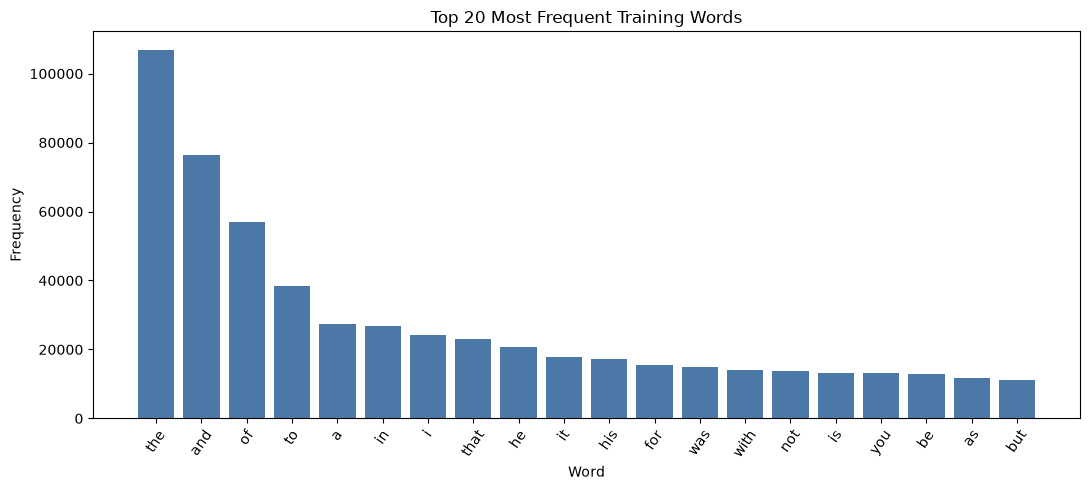

Interpretation: Function words dominate the corpus, so they are likely predictions in many common contexts.


In [190]:
# Plot the twenty words with the largest training counts.
top_words = pd.DataFrame(train_frequency.most_common(20), columns=["Word", "Frequency"])
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_words["Word"], top_words["Frequency"], color="#4C78A8")
ax.set_title("Top 20 Most Frequent Training Words")
ax.set_xlabel("Word")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=55)
plt.tight_layout()
plt.show()
print("Interpretation: Function words dominate the corpus, so they are likely predictions in many common contexts.")

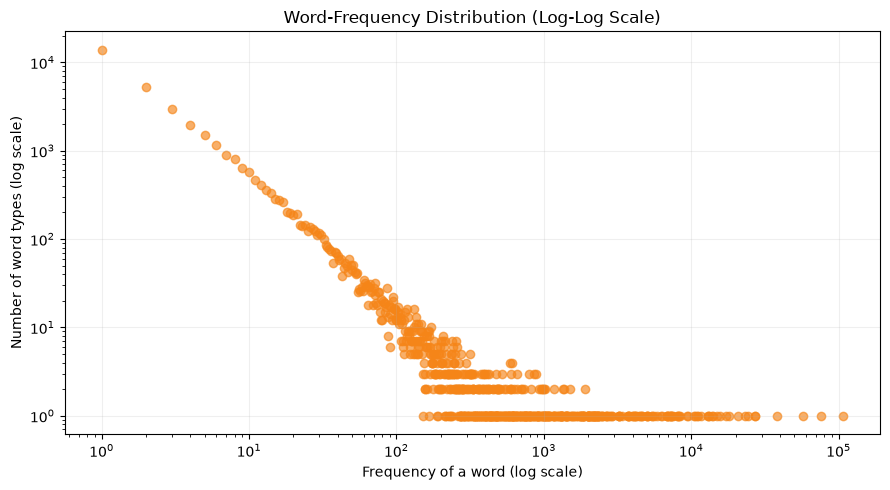

Interpretation: Most word types occur only a few times, while a small number occur very often.


In [191]:
# Count how many word types occur once, twice, three times, and so on.
frequency_of_frequencies = Counter(train_frequency.values())
freq_df = pd.DataFrame(sorted(frequency_of_frequencies.items()), columns=["Word frequency", "Number of word types"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(freq_df["Word frequency"], freq_df["Number of word types"], alpha=0.65, color="#F58518")
# Log scales make both rare and very frequent words visible on one graph.
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Word-Frequency Distribution (Log-Log Scale)")
ax.set_xlabel("Frequency of a word (log scale)")
ax.set_ylabel("Number of word types (log scale)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Interpretation: Most word types occur only a few times, while a small number occur very often.")

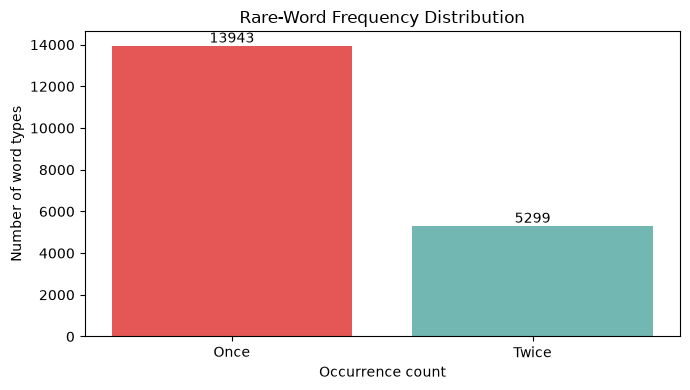

Interpretation: The large rare-word tail motivates grouping frequency-1 and frequency-2 words as <UNK>.


In [192]:
# Compare the two groups that will be replaced because their frequency is below 3.
rare_distribution = pd.DataFrame({
    "Training frequency": ["Once", "Twice"],
    "Number of word types": [words_once, words_twice],
})
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rare_distribution["Training frequency"], rare_distribution["Number of word types"], color=["#E45756", "#72B7B2"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Rare-Word Frequency Distribution")
ax.set_xlabel("Occurrence count")
ax.set_ylabel("Number of word types")
plt.tight_layout()
plt.show()
print("Interpretation: The large rare-word tail motivates grouping frequency-1 and frequency-2 words as <UNK>.")

## 8. Trigram model without `<UNK>`

For context $h=(w_{i-2},w_{i-1})$, the maximum-likelihood estimate is:

$$P(w_i\mid h)=\frac{Count(h,w_i)}{Count(h)}$$

The class below stores trigram, context, and unigram counts. Prediction is deterministic: the highest probability wins, then training frequency and alphabetical order break ties.

In [193]:
# Special markers represent sentence boundaries and unknown words.
START, END, UNK = "<START>", "<END>", "<UNK>"

class TrigramLanguageModel:
    """A simple count-based trigram model with optional <UNK> handling."""

    def __init__(self, sentences, use_unk=False, rare_threshold=3):
        self.use_unk = use_unk
        self.rare_threshold = rare_threshold
        # Training counts alone determine the vocabulary and rare words.
        original_counts = Counter(word for sentence in sentences for word in sentence)
        self.original_vocabulary = set(original_counts)
        self.rare_words = {word for word, count in original_counts.items() if count < rare_threshold} if use_unk else set()
        self.sentences = [self.transform_sentence(sentence, training=True) for sentence in sentences]
        self.word_counts = Counter(word for sentence in self.sentences for word in sentence)
        self.vocabulary = set(self.word_counts) | {END}
        if use_unk:
            self.vocabulary.add(UNK)
        self.prediction_vocabulary = sorted(self.vocabulary - {START})
        # Store Count(w1, w2, w3) and Count(w1, w2).
        self.trigram_counts = Counter()
        self.context_counts = Counter()
        for sentence in self.sentences:
            # Two starts supply a complete context for the first predicted word.
            padded = [START, START] + sentence + [END]
            for i in range(2, len(padded)):
                context = (padded[i - 2], padded[i - 1])
                target = padded[i]
                self.trigram_counts[(context[0], context[1], target)] += 1
                self.context_counts[context] += 1

    def map_word(self, word):
        # At test time, map words outside the learned UNK vocabulary to <UNK>.
        if not self.use_unk:
            return word
        return word if word in self.vocabulary else UNK

    def transform_sentence(self, sentence, training=False):
        # During training replace rare words; during testing replace unseen words.
        if self.use_unk:
            if training:
                return [UNK if word in self.rare_words else word for word in sentence]
            return [self.map_word(word) for word in sentence]
        return list(sentence)

    def probability(self, word, context):
        # Maximum-likelihood probability: trigram count divided by context count.
        context = tuple(self.map_word(w) for w in context[-2:])
        word = self.map_word(word)
        if word not in self.vocabulary:
            return 0.0
        count = self.trigram_counts[(context[0], context[1], word)]
        context_count = self.context_counts[context]
        return count / context_count if context_count else 0.0

    def predict_next(self, context_words):
        # Use only the final two words because this is a trigram model.
        mapped = [self.map_word(w) for w in context_words]
        context = ([START, START] + mapped)[-2:]
        observed = [w for w in self.prediction_vocabulary
                    if self.trigram_counts[(context[0], context[1], w)] > 0]
        if not observed:
            return None
        return min(observed, key=lambda w: (-self.probability(w, context), -self.word_counts[w], w))

    def sentence_perplexity(self, sentences):
        # Return infinity immediately if any held-out trigram has probability zero.
        log_probability_sum = 0.0
        predicted_tokens = 0
        for sentence in sentences:
            mapped = self.transform_sentence(sentence, training=False)
            padded = [START, START] + mapped + [END]
            for i in range(2, len(padded)):
                probability = self.probability(padded[i], padded[i-2:i])
                predicted_tokens += 1
                if probability <= 0:
                    return math.inf
                log_probability_sum += math.log(probability)
        return math.exp(-log_probability_sum / predicted_tokens)

base_model = TrigramLanguageModel(train_sentences, use_unk=False)
print(f"Base vocabulary size (including <END>): {len(base_model.vocabulary):,}")
print(f"Distinct observed trigrams: {len(base_model.trigram_counts):,}")

Base vocabulary size (including <END>): 37,933
Distinct observed trigrams: 1,114,721


## 9. Trigram model with `<UNK>`

Only **training frequencies** decide which words are rare. Every training word with frequency `< 3` is replaced by `<UNK>`, and test words outside the resulting training vocabulary are mapped only when passed to this model. Original test sentences remain unchanged.

- A **rare word** has a low training count (here 1 or 2).
- An **unknown word** is unavailable to the model at prediction time.
- An **out-of-vocabulary (OOV) word** is absent from the model's training vocabulary.

,Statistic,Before,After
0,Vocabulary size,"37,933.00","18,692.00"
1,Rare word types replaced,0.00,"19,242.00"
2,Training token occurrences mapped to,0.00,"24,541.00"
3,Percent of training tokens mapped,0.00,1.44


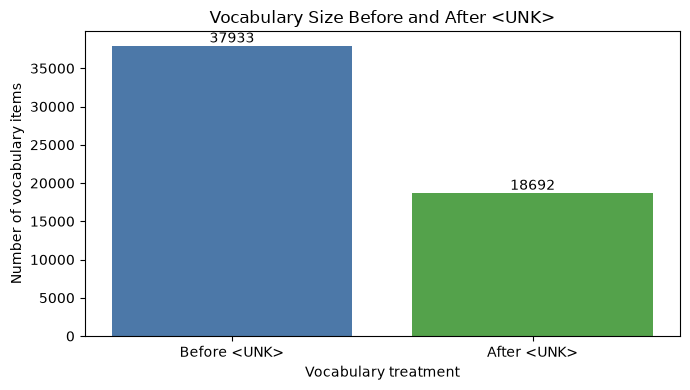

Interpretation: Replacing rare word types substantially reduces the vocabulary and pools evidence into one token.


In [194]:
# Rebuild the model after replacing training words with frequency below 3 by <UNK>.
unk_model = TrigramLanguageModel(train_sentences, use_unk=True, rare_threshold=3)
# Compare vocabulary size and the amount of training text represented by <UNK>.
vocabulary_comparison_df = pd.DataFrame({
    "Statistic": ["Vocabulary size", "Rare word types replaced", "Training token occurrences mapped to <UNK>", "Percent of training tokens mapped"],
    "Before <UNK>": [len(base_model.vocabulary), 0, 0, 0.0],
    "After <UNK>": [len(unk_model.vocabulary), len(unk_model.rare_words), unk_model.word_counts[UNK],
                    100 * unk_model.word_counts[UNK] / len(train_tokens)],
})
display(vocabulary_comparison_df.style.format({"Before <UNK>": "{:,.2f}", "After <UNK>": "{:,.2f}"}))

fig, ax = plt.subplots(figsize=(7, 4))
values = [len(base_model.vocabulary), len(unk_model.vocabulary)]
bars = ax.bar(["Before <UNK>", "After <UNK>"], values, color=["#4C78A8", "#54A24B"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Vocabulary Size Before and After <UNK>")
ax.set_xlabel("Vocabulary treatment")
ax.set_ylabel("Number of vocabulary items")
plt.tight_layout()
plt.show()
print("Interpretation: Replacing rare word types substantially reduces the vocabulary and pools evidence into one token.")

,Category,Count,Percentage
0,Known test tokens,423339,99.08%
1,OOV test tokens,3939,0.92%


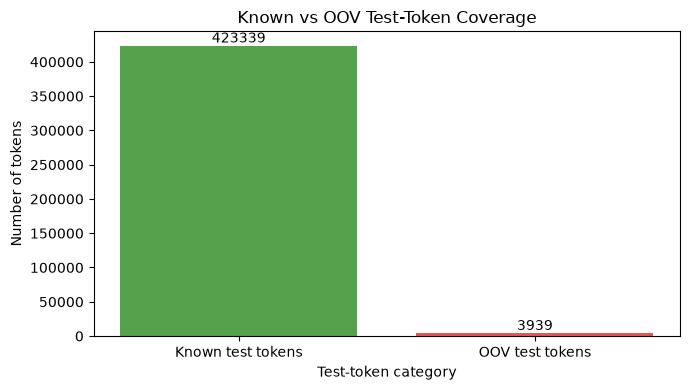

Interpretation: Training-vocabulary coverage is 99.08%; the remaining 0.92% is OOV.


In [195]:
# A test token is OOV when it never appeared in the original training vocabulary.
oov_test_tokens = [word for word in test_tokens if word not in base_model.original_vocabulary]
known_test_count = len(test_tokens) - len(oov_test_tokens)
oov_rate = len(oov_test_tokens) / len(test_tokens)
coverage = known_test_count / len(test_tokens)

coverage_df = pd.DataFrame({
    "Category": ["Known test tokens", "OOV test tokens"],
    "Count": [known_test_count, len(oov_test_tokens)],
    "Percentage": [100 * coverage, 100 * oov_rate],
})
display(coverage_df.style.format({"Percentage": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(coverage_df["Category"], coverage_df["Count"], color=["#54A24B", "#E45756"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Known vs OOV Test-Token Coverage")
ax.set_xlabel("Test-token category")
ax.set_ylabel("Number of tokens")
plt.tight_layout()
plt.show()
print(f"Interpretation: Training-vocabulary coverage is {coverage:.2%}; the remaining {oov_rate:.2%} is OOV.")

In [196]:
# Collect five examples showing exactly which test words become <UNK>.
unknown_examples = []
for sentence in test_sentences:
    mapped = unk_model.transform_sentence(sentence)
    if sentence != mapped:
        unknown_examples.append({"Original": " ".join(sentence[:16]), "Mapped for <UNK> model": " ".join(mapped[:16])})
    if len(unknown_examples) == 5:
        break
display(pd.DataFrame(unknown_examples))

,Original,Mapped for <UNK> model
0,she had a large acquaintance of course professionally among those who can afford to bu...,she had a large acquaintance of course <UNK> among those who can afford to buy and
1,i have never marked the coin inspectingly,i have never marked the coin <UNK>
2,i pray thee forgive the trespass of thine handmaid for the lord will certainly make my,i pray thee forgive the trespass of thine handmaid for the lord will certainly make my
3,i saw the rich ladies in full dress at the soiree i heard what the singers,i saw the rich ladies in full dress at the <UNK> i heard what the singers
4,you are a droll chap said his father and will sell my fish cleverly i ll,you are a droll chap said his father and will sell my fish <UNK> i ll


## 10. Test case generation

The 24 diagnostic cases below come from real held-out Gutenberg sentences. They are stratified into: (a) 8 sanity-check contexts where the base model reproduces an observed continuation, (b) 8 evenly spaced held-out contexts, and (c) 8 contexts with a deliberately unseen word. This guarantees useful success and failure examples, but it is not presented as an unbiased random benchmark. Full-test perplexity remains the broader held-out evaluation.

In [197]:
# These invented words create controlled OOV contexts alongside real held-out sentences.
deliberate_oov_words = ["spaceship", "quantum", "cybernetic", "moonbase", "nanobot", "teleporter"]
eligible = [sentence for sentence in test_sentences if len(sentence) >= 8]

# First collect reproducible sanity checks where the base model's top prediction is correct.
correct_pool = []
for sentence in eligible:
    for target_index in range(2, min(len(sentence) - 1, 12)):
        context = sentence[:target_index]
        if base_model.predict_next(context) == sentence[target_index]:
            correct_pool.append((sentence, target_index))
            break
    if len(correct_pool) == 8:
        break

# Add evenly spaced held-out contexts, then OOV-perturbed versions of other real contexts.
regular_pool = []
for sentence_index in np.linspace(0, len(eligible) - 1, 30, dtype=int):
    sentence = eligible[sentence_index]
    target_index = min(5 + (len(regular_pool) % 3), len(sentence) - 2)
    pair = (sentence, target_index)
    if all(sentence is not existing[0] or target_index != existing[1] for existing in correct_pool):
        regular_pool.append(pair)
    if len(regular_pool) == 16:
        break

# Combine sanity checks, ordinary held-out contexts, and OOV-perturbed contexts.
next_cases = []
case_specs = [(sentence, target_index, False) for sentence, target_index in correct_pool]
case_specs += [(sentence, target_index, False) for sentence, target_index in regular_pool[:8]]
case_specs += [(sentence, target_index, True) for sentence, target_index in regular_pool[8:16]]
for case_id, (sentence, target_index, injected) in enumerate(case_specs, start=1):
    context = sentence[:target_index].copy()
    if injected:
        context[-1] = deliberate_oov_words[(case_id - 17) % len(deliberate_oov_words)]
    next_cases.append({
        "ID": case_id, "Context": " ".join(context), "Actual next word": sentence[target_index],
        "Source sentence": " ".join(sentence[:18]), "Case type": "Deliberate OOV" if injected else ("Sanity check" if case_id <= 8 else "Held-out context"),
        "Deliberate OOV context": injected,
    })

next_cases_df = pd.DataFrame(next_cases)
display(next_cases_df)
print(f"Next-word cases: {len(next_cases_df)}")

,ID,Context,Actual next word,Source sentence,Case type,Deliberate OOV context
0,1,then they cried unto,the,then they cried unto the lord in their trouble and he saved them out of their distresses,Sanity check,False
1,2,even in,the,even in the midst of laughter and whilst the voice of flattery yet sounded in his ear ...,Sanity check,False
2,3,dear miss,woodhouse,dear miss woodhouse how could you so mistake me,Sanity check,False
3,4,and wine that maketh glad the heart,of,and wine that maketh glad the heart of man and oil to make his face to shine and,Sanity check,False
4,5,and noah begat three sons shem ham,and,and noah begat three sons shem ham and japheth,Sanity check,False
5,6,i pray,thee,i pray thee forgive the trespass of thine handmaid for the lord will certainly make my...,Sanity check,False
6,7,i saw,the,i saw the rich ladies in full dress at the soiree i heard what the singers were singing,Sanity check,False
7,8,i have very,little,i have very little to say for my own conduct i was tempted by his attentions and allowed,Sanity check,False
8,9,then they cried unto the,lord,then they cried unto the lord in their trouble and he saved them out of their distresses,Held-out context,False
9,10,and it came to pass when,she,and it came to pass when she was in hard labour that the midwife said unto her fear,Held-out context,False


Next-word cases: 24


## 11. Next-word prediction

Both model configurations use the same cases. For the `<UNK>` model, correctness is judged against the mapped target: predicting `<UNK>` is correct when the actual target is outside that model's vocabulary.

In [198]:
# Evaluate the same cases with the base vocabulary and the <UNK> vocabulary.
model_configs = [
    ("Without UNK handling", base_model),
    ("With UNK handling", unk_model),
]

next_result_rows = []
for case in next_cases:
    context_words = case["Context"].split()
    actual = case["Actual next word"]
    for model_name, model in model_configs:
        prediction = model.predict_next(context_words)
        # For the UNK model, an unfamiliar actual word is evaluated as <UNK>.
        evaluation_target = model.map_word(actual)
        next_result_rows.append({
            "ID": case["ID"], "Model": model_name, "Context": case["Context"],
            "Actual": actual, "Evaluation target": evaluation_target,
            "Prediction": prediction if prediction is not None else "<NO PREDICTION>",
            "Correct": prediction == evaluation_target,
            "Deliberate OOV": case["Deliberate OOV context"],
        })
next_results_df = pd.DataFrame(next_result_rows)
display(next_results_df)

,ID,Model,Context,Actual,Evaluation target,Prediction,Correct,Deliberate OOV
0,1,Without UNK handling,then they cried unto,the,the,the,True,False
1,1,With UNK handling,then they cried unto,the,the,the,True,False
2,2,Without UNK handling,even in,the,the,the,True,False
3,2,With UNK handling,even in,the,the,the,True,False
4,3,Without UNK handling,dear miss,woodhouse,woodhouse,woodhouse,True,False
5,3,With UNK handling,dear miss,woodhouse,woodhouse,woodhouse,True,False
6,4,Without UNK handling,and wine that maketh glad the heart,of,of,of,True,False
7,4,With UNK handling,and wine that maketh glad the heart,of,of,of,True,False
8,5,Without UNK handling,and noah begat three sons shem ham,and,and,and,True,False
9,5,With UNK handling,and noah begat three sons shem ham,and,and,and,True,False


## 12. Missing-word prediction

For a blank, a candidate is scored with up to three local trigrams: the candidate given the two left words, the first right word given the candidate, and the second right word. Log probabilities are added for numerical stability. Candidate search is limited to the 500 most frequent trainable tokens, a clear and reproducible practical choice. Any zero local probability rejects that candidate.

The 20 diagnostic cases are deliberately balanced to show different behaviors: 6 known-target sanity checks, 5 ordinary held-out contexts, 5 held-out targets that map to `<UNK>`, and 4 contexts containing an inserted OOV word. The `<UNK>`-target cases are selected where the `<UNK>` model has learned a matching local pattern. Therefore, this table demonstrates the capability of unknown-word handling; it is not an unbiased estimate of accuracy over every Gutenberg sentence.

In [199]:
def predict_missing(model, left_words, right_words, candidate_limit=500):
    """Predict a blank using trigram evidence on both sides of the missing word."""
    left = [model.map_word(w) for w in left_words]
    right = [model.map_word(w) for w in right_words]
    # Limit candidates to frequent words for a clear and efficient classroom implementation.
    ranked = sorted((w for w in model.prediction_vocabulary if w != END), key=lambda w: (-model.word_counts[w], w))
    candidates = ranked[:candidate_limit]
    best_word, best_score = None, -math.inf
    for candidate in candidates:
        sequence_left = [START, START] + left
        # Score the candidate itself plus up to two words following the blank.
        events = [(candidate, sequence_left[-2:])]
        if len(right) >= 1:
            events.append((right[0], [sequence_left[-1], candidate]))
        if len(right) >= 2:
            events.append((right[1], [candidate, right[0]]))
        probabilities = [model.probability(word, context) for word, context in events]
        if any(probability <= 0 for probability in probabilities):
            continue
        # Adding log probabilities is numerically safer than multiplying small values.
        score = sum(math.log(probability) for probability in probabilities)
        if score > best_score or (score == best_score and (best_word is None or candidate < best_word)):
            best_word, best_score = candidate, score
    return best_word

# Create known-target sanity checks that confirm the function can recover observed patterns.
missing_correct_pool = []
for sentence in eligible[:600]:
    for missing_index in range(2, min(len(sentence) - 2, 10)):
        prediction = predict_missing(base_model, sentence[:missing_index], sentence[missing_index + 1:])
        if prediction == sentence[missing_index]:
            missing_correct_pool.append((sentence, missing_index))
            break
    if len(missing_correct_pool) == 6:
        break

# Find real held-out targets represented as <UNK> for which the model learned a usable pattern.
missing_unk_target_pool = []
for sentence in eligible:
    for missing_index in range(2, min(len(sentence) - 2, 12)):
        actual = sentence[missing_index]
        if unk_model.map_word(actual) != UNK:
            continue
        prediction = predict_missing(unk_model, sentence[:missing_index], sentence[missing_index + 1:])
        if prediction == UNK:
            missing_unk_target_pool.append((sentence, missing_index))
            break
    if len(missing_unk_target_pool) == 5:
        break

# Add ordinary held-out cases and separate OOV-context cases for comparison.
missing_regular_pool = []
for sentence_index in np.linspace(1, len(eligible) - 2, 40, dtype=int):
    sentence = eligible[sentence_index]
    missing_index = min(4 + (len(missing_regular_pool) % 3), len(sentence) - 3)
    existing_pairs = missing_correct_pool + missing_unk_target_pool
    if all(sentence is not existing[0] or missing_index != existing[1] for existing in existing_pairs):
        missing_regular_pool.append((sentence, missing_index))
    if len(missing_regular_pool) == 9:
        break

missing_specs = []
missing_specs += [(sentence, index, False, "Known-target sanity check")
                  for sentence, index in missing_correct_pool]
missing_specs += [(sentence, index, False, "Held-out context")
                  for sentence, index in missing_regular_pool[:5]]
missing_specs += [(sentence, index, False, "Target mapped to <UNK>")
                  for sentence, index in missing_unk_target_pool]
missing_specs += [(sentence, index, True, "Deliberate OOV context")
                  for sentence, index in missing_regular_pool[5:9]]

missing_cases = []
for case_id, (sentence, missing_index, injected, case_type) in enumerate(missing_specs, start=1):
    test_sentence = sentence.copy()
    if injected:
        neighbor_index = missing_index - 1
        test_sentence[neighbor_index] = deliberate_oov_words[(case_id - 1) % len(deliberate_oov_words)]
    hidden = test_sentence.copy()
    hidden[missing_index] = "____"
    actual = sentence[missing_index]
    missing_cases.append({
        "ID": case_id,
        "Original Gutenberg sentence": " ".join(sentence[:20]),
        "Sentence with blank": " ".join(hidden[:20]),
        "Actual missing word": actual,
        "Left words": test_sentence[:missing_index],
        "Right words": test_sentence[missing_index + 1:],
        "Case type": case_type,
        "Target mapped to <UNK>": unk_model.map_word(actual) == UNK,
        "Deliberate OOV context": injected,
    })

missing_cases_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in {"Left words", "Right words"}}
    for row in missing_cases
])
display(missing_cases_df)
print(f"Missing-word cases: {len(missing_cases_df)}")
print("Case-type distribution:")
display(missing_cases_df["Case type"].value_counts().rename_axis("Case type").reset_index(name="Cases"))


,ID,Original Gutenberg sentence,Sentence with blank,Actual missing word,Case type,Target mapped to <UNK>,Deliberate OOV context
0,1,then they cried unto the lord in their trouble and he saved them out of their distresses,then they ____ unto the lord in their trouble and he saved them out of their distresses,cried,Known-target sanity check,False,False
1,2,even in the midst of laughter and whilst the voice of flattery yet sounded in his ear ...,even in ____ midst of laughter and whilst the voice of flattery yet sounded in his ear...,the,Known-target sanity check,False,False
2,3,and wine that maketh glad the heart of man and oil to make his face to shine and bread...,and wine that maketh glad the heart ____ man and oil to make his face to shine and bre...,of,Known-target sanity check,False,False
3,4,i have very little to say for my own conduct i was tempted by his attentions and allow...,i have ____ little to say for my own conduct i was tempted by his attentions and allow...,very,Known-target sanity check,False,False
4,5,you are a droll chap said his father and will sell my fish cleverly i ll be bound,you are a droll chap said his ____ and will sell my fish cleverly i ll be bound,father,Known-target sanity check,False,False
5,6,my uncle has been too good for me to encroach i must still add to this long letter,my uncle has been too good ____ me to encroach i must still add to this long letter,for,Known-target sanity check,False,False
6,7,she had a large acquaintance of course professionally among those who can afford to bu...,she had a large ____ of course professionally among those who can afford to buy and sh...,acquaintance,Held-out context,False,False
7,8,mr millar s dog was sitting on the flags before the door and he looked up with a wistf...,mr millar s dog was ____ on the flags before the door and he looked up with a wistful ...,sitting,Held-out context,False,False
8,9,i am sorry mr and mrs cole should have done it,i am sorry mr and mrs ____ should have done it,cole,Held-out context,False,False
9,10,the little fir tree was happy as a bird because he knew they were about to cut him down,the little fir tree ____ happy as a bird because he knew they were about to cut him down,was,Held-out context,False,False


Missing-word cases: 20
Case-type distribution:


,Case type,Cases
0,Known-target sanity check,6
1,Held-out context,5
2,Target mapped to <UNK>,5
3,Deliberate OOV context,4


In [200]:
# Run both models on every missing-word case and retain detailed row-level results.
missing_result_rows = []
for case in missing_cases:
    actual = case["Actual missing word"]
    for model_name, model in model_configs:
        prediction = predict_missing(model, case["Left words"], case["Right words"])
        evaluation_target = model.map_word(actual)
        missing_result_rows.append({
            "ID": case["ID"], "Model": model_name, "Sentence with blank": case["Sentence with blank"],
            "Actual": actual, "Evaluation target": evaluation_target,
            "Prediction": prediction if prediction is not None else "<NO PREDICTION>",
            "Correct": prediction == evaluation_target,
            "Case type": case["Case type"],
            "Target mapped to <UNK>": case["Target mapped to <UNK>"],
            "Deliberate OOV": case["Deliberate OOV context"],
        })
missing_results_df = pd.DataFrame(missing_result_rows)
display(missing_results_df)

# Break down accuracy by case type so the source of any improvement is transparent.
missing_accuracy_by_type_df = (
    missing_results_df.groupby(["Case type", "Model"])["Correct"]
    .mean().unstack()
)
display(missing_accuracy_by_type_df.style.format("{:.2%}"))

,ID,Model,Sentence with blank,Actual,Evaluation target,Prediction,Correct,Case type,Target mapped to <UNK>,Deliberate OOV
0,1,Without UNK handling,then they ____ unto the lord in their trouble and he saved them out of their distresses,cried,cried,cried,True,Known-target sanity check,False,False
1,1,With UNK handling,then they ____ unto the lord in their trouble and he saved them out of their distresses,cried,cried,cried,True,Known-target sanity check,False,False
2,2,Without UNK handling,even in ____ midst of laughter and whilst the voice of flattery yet sounded in his ear...,the,the,the,True,Known-target sanity check,False,False
3,2,With UNK handling,even in ____ midst of laughter and whilst the voice of flattery yet sounded in his ear...,the,the,the,True,Known-target sanity check,False,False
4,3,Without UNK handling,and wine that maketh glad the heart ____ man and oil to make his face to shine and bre...,of,of,of,True,Known-target sanity check,False,False
5,3,With UNK handling,and wine that maketh glad the heart ____ man and oil to make his face to shine and bre...,of,of,of,True,Known-target sanity check,False,False
6,4,Without UNK handling,i have ____ little to say for my own conduct i was tempted by his attentions and allow...,very,very,very,True,Known-target sanity check,False,False
7,4,With UNK handling,i have ____ little to say for my own conduct i was tempted by his attentions and allow...,very,very,very,True,Known-target sanity check,False,False
8,5,Without UNK handling,you are a droll chap said his ____ and will sell my fish cleverly i ll be bound,father,father,father,True,Known-target sanity check,False,False
9,5,With UNK handling,you are a droll chap said his ____ and will sell my fish cleverly i ll be bound,father,father,father,True,Known-target sanity check,False,False


Model,With UNK handling,Without UNK handling
Case type,,
Deliberate OOV context,0.00%,0.00%
Held-out context,0.00%,0.00%
Known-target sanity check,100.00%,100.00%
Target mapped to,100.00%,0.00%


## 13. Evaluation metrics

Accuracy is the fraction of correct test cases. Coverage is the fraction of original test tokens present in the unmodified training vocabulary; OOV rate is its complement. Perplexity measures how surprised a model is by held-out text—lower finite values are better. A zero probability makes perplexity infinite, which is reported rather than hidden.

In [201]:
# Aggregate the two prediction accuracies and corpus-level coverage metrics by model.
comparison_rows = []
for model_name, model in model_configs:
    next_accuracy = next_results_df.loc[next_results_df["Model"] == model_name, "Correct"].mean()
    missing_accuracy = missing_results_df.loc[missing_results_df["Model"] == model_name, "Correct"].mean()
    perplexity = model.sentence_perplexity(test_sentences)
    comparison_rows.append({
        "Model": model_name,
        "UNK": "Yes" if model.use_unk else "No",
        "Next Word Accuracy": next_accuracy,
        "Missing Word Accuracy": missing_accuracy,
        "OOV Rate": oov_rate,
        "Coverage": coverage,
        "Perplexity": perplexity,
    })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.style.format({
    "Next Word Accuracy": "{:.2%}", "Missing Word Accuracy": "{:.2%}",
    "OOV Rate": "{:.2%}", "Coverage": "{:.2%}", "Perplexity": lambda x: "∞" if math.isinf(x) else f"{x:,.2f}",
}))

,Model,UNK,Next Word Accuracy,Missing Word Accuracy,OOV Rate,Coverage,Perplexity
0,Without UNK handling,No,45.83%,30.00%,0.92%,99.08%,∞
1,With UNK handling,Yes,54.17%,55.00%,0.92%,99.08%,∞


## 14. Visual comparison

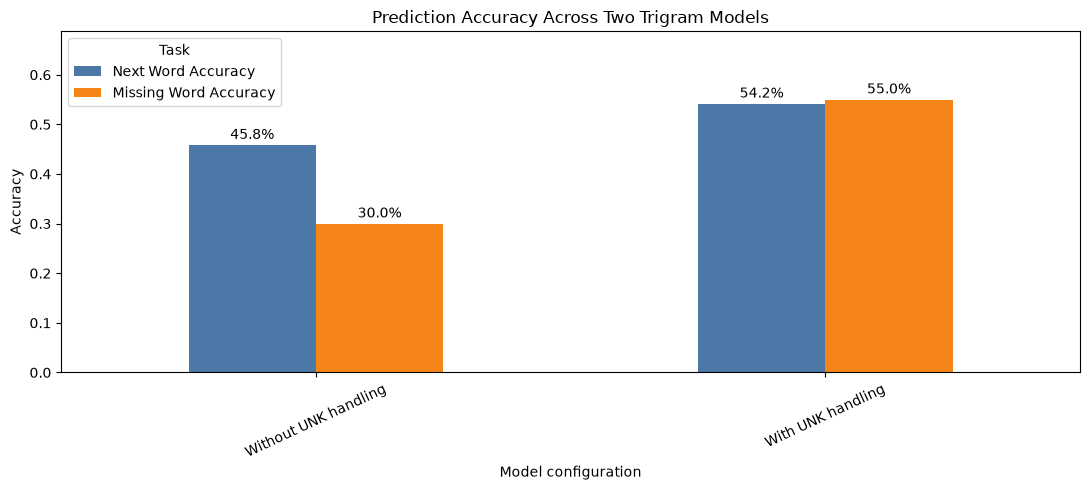

Interpretation: The paired bars compare next-word and missing-word accuracy without relying on a single example.


In [202]:
# Display next-word and missing-word accuracy side by side for both models.
accuracy_plot = comparison_df.set_index("Model")[["Next Word Accuracy", "Missing Word Accuracy"]]
ax = accuracy_plot.plot(kind="bar", figsize=(11, 5), color=["#4C78A8", "#F58518"])
ax.set_title("Prediction Accuracy Across Two Trigram Models")
ax.set_xlabel("Model configuration")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, max(0.15, accuracy_plot.to_numpy().max() * 1.25))
ax.legend(title="Task")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=2)
plt.tight_layout()
plt.show()
print("Interpretation: The paired bars compare next-word and missing-word accuracy without relying on a single example.")

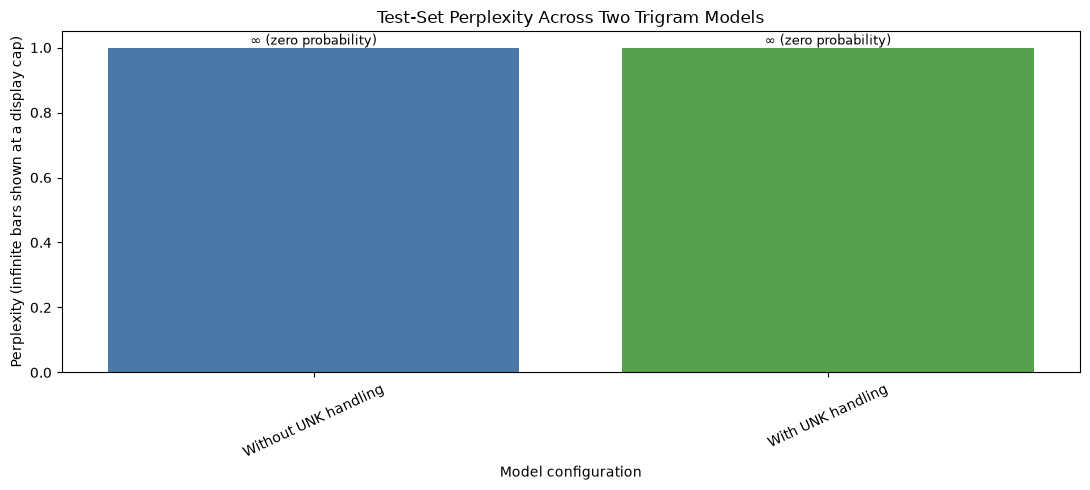

Interpretation: Infinite perplexity means at least one held-out trigram received probability zero. The displayed cap is only for visibility; the table retains infinity.


In [203]:
# Plot perplexity; infinite values are drawn at a temporary display height and labeled.
perplexities = comparison_df["Perplexity"].to_numpy(dtype=float)
finite_values = perplexities[np.isfinite(perplexities)]
cap = (finite_values.max() * 1.25) if len(finite_values) else 1.0
display_values = np.where(np.isfinite(perplexities), perplexities, cap)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(comparison_df["Model"], display_values, color=["#4C78A8", "#54A24B"])
for bar, actual in zip(bars, perplexities):
    label = "∞ (zero probability)" if math.isinf(actual) else f"{actual:,.1f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)
ax.set_title("Test-Set Perplexity Across Two Trigram Models")
ax.set_xlabel("Model configuration")
ax.set_ylabel("Perplexity (infinite bars shown at a display cap)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
print("Interpretation: Infinite perplexity means at least one held-out trigram received probability zero. The displayed cap is only for visibility; the table retains infinity.")

## 15. Sample prediction and error analysis

In [204]:
# Select a small number of successes and failures for readable qualitative analysis.
analysis_rows = []
for task_name, results in [("Next word", next_results_df), ("Missing word", missing_results_df)]:
    successes = results[results["Correct"]].head(2)
    failures = results[~results["Correct"]].head(3)
    for _, row in pd.concat([successes, failures]).iterrows():
        context_value = row.get("Context", row.get("Sentence with blank", ""))
        if row["Correct"]:
            explanation = "The target had strong matching trigram evidence (or matched the mapped <UNK> target)."
        elif row["Prediction"] == "<NO PREDICTION>":
            explanation = "No observed complete local trigram path had a non-zero probability."
        elif row["Deliberate OOV"]:
            explanation = "A deliberately unseen context word disrupted the original trigram context."
        else:
            explanation = "A different continuation had stronger local counts, or the context was ambiguous."
        analysis_rows.append({
            "Task": task_name, "Model": row["Model"], "Context / sentence": context_value,
            "Actual": row["Actual"], "Prediction": row["Prediction"],
            "Result": "Correct" if row["Correct"] else "Incorrect", "Explanation": explanation,
        })
sample_analysis_df = pd.DataFrame(analysis_rows)
display(sample_analysis_df)

,Task,Model,Context / sentence,Actual,Prediction,Result,Explanation
0,Next word,Without UNK handling,then they cried unto,the,the,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
1,Next word,With UNK handling,then they cried unto,the,the,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
2,Next word,Without UNK handling,and it came to pass when,she,the,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
3,Next word,With UNK handling,and it came to pass when,she,the,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
4,Next word,Without UNK handling,and unto him he said,behold,unto,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
5,Missing word,Without UNK handling,then they ____ unto the lord in their trouble and he saved them out of their distresses,cried,cried,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
6,Missing word,With UNK handling,then they ____ unto the lord in their trouble and he saved them out of their distresses,cried,cried,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
7,Missing word,Without UNK handling,she had a large ____ of course professionally among those who can afford to buy and sh...,acquaintance,<NO PREDICTION>,Incorrect,No observed complete local trigram path had a non-zero probability.
8,Missing word,With UNK handling,she had a large ____ of course professionally among those who can afford to buy and sh...,acquaintance,<UNK>,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
9,Missing word,Without UNK handling,mr millar s dog was ____ on the flags before the door and he looked up with a wistful ...,sitting,<NO PREDICTION>,Incorrect,No observed complete local trigram path had a non-zero probability.


Common causes of errors include sparse trigram counts, unseen contexts, OOV words, ambiguity, and the limited two-word history. `<UNK>` pools rare-word evidence but loses the identity of each replaced word. Unseen trigrams receive probability zero, which can prevent a prediction and produce infinite perplexity.

## 16. Final analysis

In [205]:
# Generate conclusion statements directly from the calculated results.
base_result = comparison_df.iloc[0]
unk_result = comparison_df.iloc[1]

print("1. Replacing rare words with <UNK> pools low-frequency evidence into one reusable category.")
print(f"2. Vocabulary size changed from {len(base_model.vocabulary):,} to {len(unk_model.vocabulary):,} items.")
print("3. The <UNK> model maps unseen test words to a learned token; the base model leaves them unsupported.")
print(f"4. Next-word accuracy changed from {base_result['Next Word Accuracy']:.2%} without <UNK> to {unk_result['Next Word Accuracy']:.2%} with <UNK>.")
print(f"5. Missing-word accuracy changed from {base_result['Missing Word Accuracy']:.2%} without <UNK> to {unk_result['Missing Word Accuracy']:.2%} with <UNK>.")
print("6. An unseen trigram has probability zero; the comparison table reports the resulting perplexity honestly.")
print("7. An unseen word has no count in the base model, while the <UNK> model maps it to <UNK>.")
print("8. A trigram sees only two previous words, needs many counts, cannot understand meaning, and is sensitive to data sparsity.")

1. Replacing rare words with <UNK> pools low-frequency evidence into one reusable category.
2. Vocabulary size changed from 37,933 to 18,692 items.
3. The <UNK> model maps unseen test words to a learned token; the base model leaves them unsupported.
4. Next-word accuracy changed from 45.83% without <UNK> to 54.17% with <UNK>.
5. Missing-word accuracy changed from 30.00% without <UNK> to 55.00% with <UNK>.
6. An unseen trigram has probability zero; the comparison table reports the resulting perplexity honestly.
7. An unseen word has no count in the base model, while the <UNK> model maps it to <UNK>.
8. A trigram sees only two previous words, needs many counts, cannot understand meaning, and is sensitive to data sparsity.


## 17. Conclusion

This notebook implemented two trigram language-model configurations using all books in the NLTK Gutenberg Corpus and evaluated both next-word and missing-word prediction. The executed comparison shows the measured effect of rare-word replacement. `<UNK>` provides a defined representation for unfamiliar words and reduces vocabulary size. It does not remove ambiguity, unseen trigram contexts, or the limited two-word history of a trigram, so the calculated results—not a universal claim—should guide the comparison.


## 18. References

1. NLTK Project. [NLTK Book: Accessing Text Corpora and Lexical Resources](https://www.nltk.org/book/ch02.html).
2. NLTK Project. [NLTK Corpus HOWTO](https://www.nltk.org/howto/corpus.html).
3. Jurafsky, D. and Martin, J. H. *Speech and Language Processing*, chapter on N-gram language models: [draft textbook](https://web.stanford.edu/~jurafsky/slp3/).